In [1]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import pyplot as plt

from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, Dropout

from keras.utils import image_dataset_from_directory
from keras.models import Sequential

In [2]:

train_dataset = image_dataset_from_directory(
    ".\\train",
    image_size=(128, 128),
    labels="inferred",
    label_mode="binary",
    class_names=["mascarilla", "no_mascarilla"],
    validation_split=0.2,
    subset="training",
    seed=42
)

val_dataset = image_dataset_from_directory(
    ".\\train",
    image_size=(128, 128),
    labels="inferred",
    label_mode="binary",
    class_names=["mascarilla", "no_mascarilla"],
    validation_split=0.2,
    subset="validation",
    seed=42
)

test_dataset = image_dataset_from_directory(
    ".\\test",
    image_size=(128, 128),
    labels="inferred",
    label_mode="binary",
    class_names=["mascarilla", "no_mascarilla"],
)

Found 656 files belonging to 2 classes.
Using 525 files for training.
Found 656 files belonging to 2 classes.
Using 131 files for validation.
Found 160 files belonging to 2 classes.


In [4]:
normalization = Rescaling(1.0 / 255)

data_augmentation = Sequential(
    [
        RandomFlip("horizontal"),  # Volteo horizontal
        RandomRotation(0.2),  # Rotaciones 20% de 360º
        RandomZoom(0.1),  # Zoom hasta 10%
        RandomTranslation(0.1, 0.1),  # Desplaz. vertical y horizontal
    ]
)

train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization(x)), y))
val_dataset = val_dataset.map(lambda x, y: (normalization(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization(x), y))

In [5]:
model = keras.Sequential(
    [
        Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(128, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        Flatten(),
        Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01)),
        #Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
        #Dense(2, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
    #optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = model.fit( train_dataset, validation_data=val_dataset, epochs=20, batch_size=32, callbacks=[early_stop] )

Epoch 1/20


17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 605ms/step - accuracy: 0.7332 - loss: 4.8780 - val_accuracy: 0.8397 - val_loss: 2.9195
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 575ms/step - accuracy: 0.9037 - loss: 3.3598 - val_accuracy: 0.8550 - val_loss: 2.7867
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 644ms/step - accuracy: 0.9407 - loss: 2.6572 - val_accuracy: 0.9160 - val_loss: 2.3622
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 594ms/step - accuracy: 0.9379 - loss: 2.4799 - val_accuracy: 0.8397 - val_loss: 2.4525
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 581ms/step - accuracy: 0.9501 - loss: 2.0494 - val_accuracy: 0.5115 - val_loss: 7.3369
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 578ms/step - accuracy: 0.9262 - loss: 1.8254 - val_accuracy: 0.5115 - val_loss: 5.8617


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
               precision    recall  f1-score   support

   Mascarilla       0.51      0.40      0.45        80
No Mascarilla       0.51      0.61      0.55        80

     accuracy                           0.51       160
    macro avg       0.51      0.51      0.50       160
 weighted avg       0.51      0.51      0.50       160



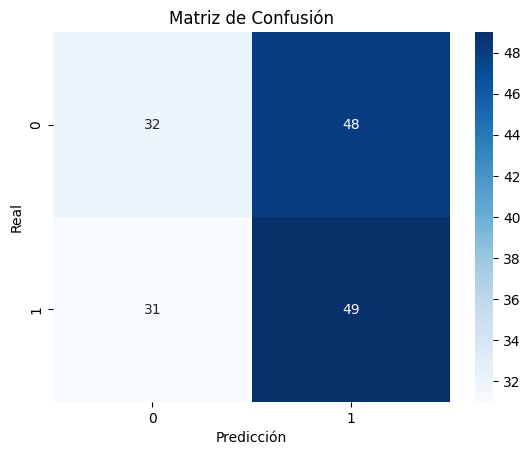

In [7]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred = model.predict(test_dataset)
y_pred = (y_pred > 0.5).astype("int32").flatten()

# Reporte de clasificación
print(classification_report(y_true, y_pred, target_names=["Mascarilla", "No Mascarilla"]))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8966 - loss: 2.3668
Pérdida en test: 2.4444
Precisión en test: 0.8813


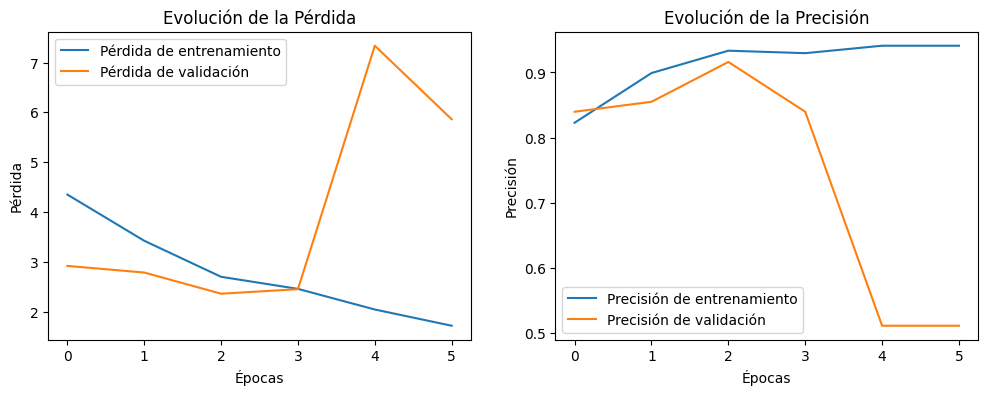

In [14]:
# Evaluación del modelo en el conjunto de test
loss, accuracy = model.evaluate(test_dataset)

print(f"Pérdida en test: {loss:.4f}")
print(f"Precisión en test: {accuracy:.4f}")

# Extraer los valores del historial
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(train_loss))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Pérdida de entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Evolución de la Pérdida')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Precisión de entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión de validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Evolución de la Precisión')

plt.show()